# 9. Suavizamiento exponencial Holt-Winters y comparacion final

In [1]:
%run functions.ipynb

In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = load_data()
y_train = df.yt_true.iloc[:-24].values.astype(float)

result = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
).fit()

df["yt_pred_holt_winters"] = np.r_[result.fittedvalues, result.forecast(24)]

plot_time_series(df[["yt_true", "yt_pred_holt_winters"]])

<Figure size 1200x400 with 1 Axes>

In [3]:
metrics = compute_evaluation_metrics(df)
save_forecasts(df)
save_metrics(metrics)
metrics

,Metrics,yt_pred_holt_winters
0,MSE Train,49179.33
1,MSE Test,201970.56
2,MAE Train,163.07
3,MAE Test,348.65


## Comparacion de todos los modelos

In [4]:
comparacion = pd.read_csv("../submission/metrics.csv", index_col="Metrics").T
comparacion.columns.name = None
comparacion.sort_values("MAE Test")

,MSE Train,MSE Test,MAE Train,MAE Test
yt_pred_ar,50533.08,92327.44,160.48,224.08
yt_pred_d1d12_ar,46784.99,132232.41,159.49,286.58
yt_pred_sarima,57331.27,140040.00,174.32,304.02
yt_pred_holt_winters,49179.33,201970.56,163.07,348.65
yt_pred_mlp,126590.20,354554.33,252.74,443.28
yt_pred_log_trend_month,99264.28,369934.77,237.83,539.29
yt_pred_trend,376582.81,1146851.21,459.62,781.18
yt_pred_trend_month,103217.67,738282.04,259.03,804.13
yt_pred_trend_sincos,111966.93,754794.64,271.17,804.82


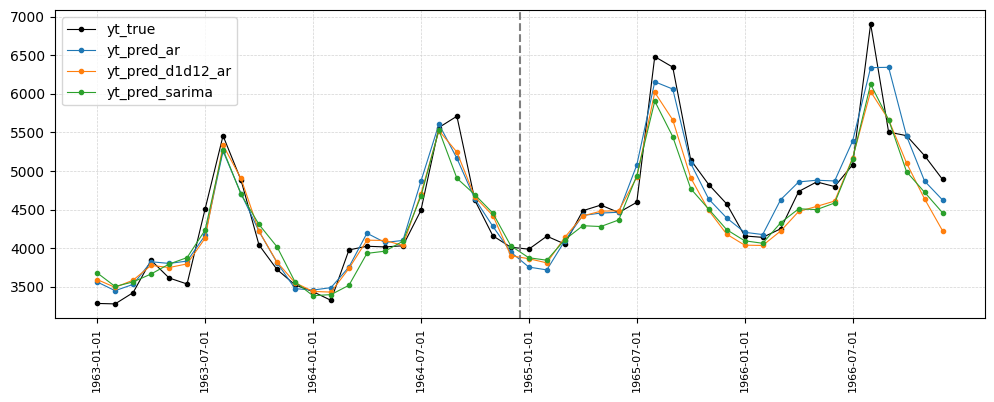

In [5]:
forecasts = pd.read_csv("../submission/forecasts.csv", index_col=0)

mejores = comparacion.sort_values("MAE Test").index[:3]

tramo = forecasts.iloc[-48:]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tramo.index, tramo.yt_true, ".-k", linewidth=0.8, label="yt_true")
for columna in mejores:
    ax.plot(tramo.index, tramo[columna], ".-", linewidth=0.8, label=columna)
ax.axvline(len(tramo) - 24.5, linestyle="--", color="gray")
ax.set_xticks(range(0, 48, 6))
ax.set_xticklabels(tramo.index[::6], rotation=90, fontsize=8)
ax.grid(color="lightgray", linestyle="--", linewidth=0.5)
ax.legend()
plt.show()

**Conclusiones**

- Los modelos con tendencia determinista (notebooks 1 a 4) no siguen la aceleracion de la tendencia al final de la serie; el logaritmo ayuda porque la estacionalidad es multiplicativa.
- Los modelos que usan la historia reciente (autorregresivos, SARIMA, Holt-Winters) reducen el error de prueba a menos de la mitad respecto a los modelos aditivos de tendencia + estacionalidad.
- El mejor modelo es el autorregresivo lineal con 36 rezagos (notebook 5), seguido de la diferenciacion d1 d12 con autorregresivo y del SARIMA. En los dos autorregresivos el numero de rezagos se eligio con una validacion dentro del entrenamiento, sin mirar el tramo de prueba.
- La red neuronal no compensa su complejidad con tan pocos datos.